In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Training data
X = [2, 4, 6]
y = [50, 70, 90]
m = len(X)


In [3]:
def compute_cost_manual(X, y, theta0, theta1):
    m = len(X)
    total_error = 0
    for i in range(m):
        h = theta0 + theta1 * X[i]
        total_error += (h - y[i])**2
    return total_error / (2*m)


In [4]:
import random

def stochastic_gradient_descent_manual(X, y, theta0, theta1, alpha, num_epochs):
    m = len(X)
    cost_history = []

    for epoch in range(num_epochs):
        # shuffle data for each epoch
        data = list(zip(X, y))
        random.shuffle(data)

        for xi, yi in data:
            h = theta0 + theta1 * xi
            error = h - yi

            # update immediately for each example
            theta0 = theta0 - alpha * error
            theta1 = theta1 - alpha * error * xi

        # record cost at the end of each epoch
        cost_history.append(compute_cost_manual(X, y, theta0, theta1))

    return theta0, theta1, cost_history


In [5]:
theta0, theta1 = 0, 0   # initialize
alpha = 0.01
num_epochs = 50

theta0_sgd, theta1_sgd, cost_sgd = stochastic_gradient_descent_manual(X, y, theta0, theta1, alpha, num_epochs)

print("θ0 (SGD):", theta0_sgd)
print("θ1 (SGD):", theta1_sgd)
print("Final cost:", cost_sgd[-1])


θ0 (SGD): 8.489740334462649
θ1 (SGD): 14.414913869819607
Final cost: 33.402195603518074


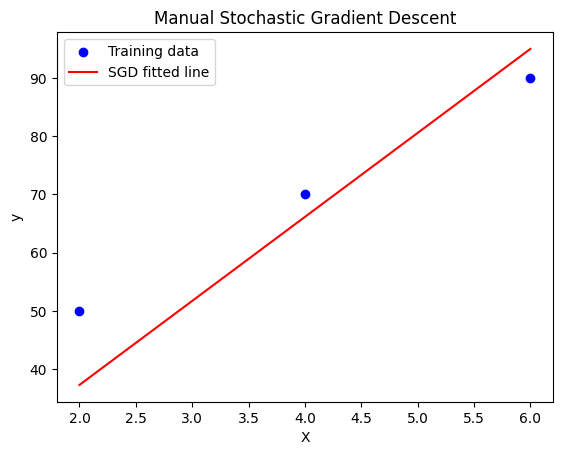

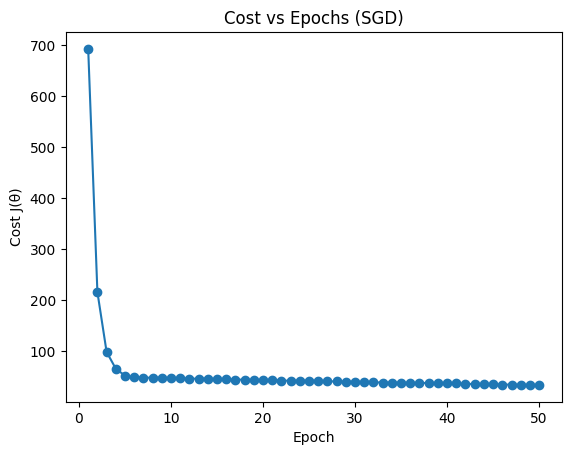

In [6]:
# Line fit after SGD
x_line = np.linspace(min(X), max(X), 100)
y_line = theta0_sgd + theta1_sgd * x_line

plt.scatter(X, y, color="blue", label="Training data")
plt.plot(x_line, y_line, "r-", label="SGD fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Manual Stochastic Gradient Descent")
plt.show()

# Cost history
plt.plot(range(1, len(cost_sgd)+1), cost_sgd, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Cost J(θ)")
plt.title("Cost vs Epochs (SGD)")
plt.show()


In [7]:

new_x=np.array([10,15])
predictions = theta0_sgd + theta1_sgd * new_x
print("Predictions for new inputs (SGD):", predictions)

Predictions for new inputs (SGD): [152.63887903 224.71344838]


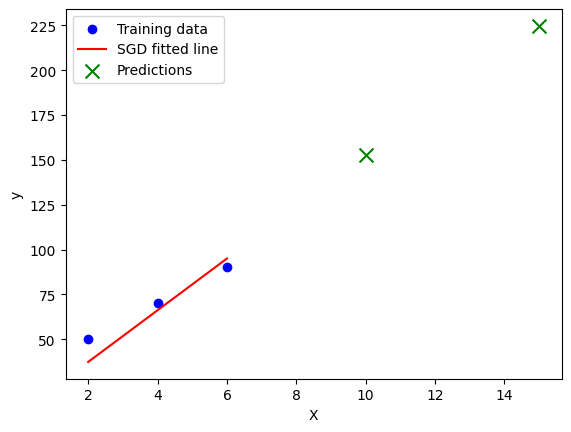

In [8]:
# predict data to plot
plt.scatter(X, y, color="blue", label="Training data")
plt.plot(x_line, y_line, "r-", label="SGD fitted line")
plt.scatter(new_x, predictions, color="green", marker="x", s=100, label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()